In [1]:
import pandas as pd
import numpy as np

In [2]:
scenario_df = pd.read_csv(
    "/content/scenario_results.csv"
)

route_clusters = pd.read_csv(
    "/content/route_clusters.csv"
)

df = pd.read_csv(
    "/content/nassau_candy_cleaned.csv"
)

print("Scenario:", scenario_df.shape)
print("Clusters:", route_clusters.shape)
print("Cleaned:", df.shape)

Scenario: (770, 16)
Clusters: (4, 11)
Cleaned: (10194, 32)


In [3]:
recommendations = scenario_df[
    scenario_df["Is_Current"] == False
].copy()

print(recommendations.shape)

(616, 16)


In [4]:
recommendations["Speed_Score"] = (
    recommendations["Lead_Time_Reduction_%"]
    .clip(lower=0)
)

In [5]:
recommendations["Profit_Safety_Score"] = (
    recommendations["Profit_Margin"] * 100
)

In [6]:
def min_max(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.ones(len(series)),
            index=series.index
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )

recommendations["Speed_Normalized"] = min_max(
    recommendations["Speed_Score"]
)

recommendations["Profit_Normalized"] = min_max(
    recommendations["Profit_Safety_Score"]
)

In [7]:
SPEED_WEIGHT = 0.6
PROFIT_WEIGHT = 0.4

recommendations["Optimization_Score"] = (
    recommendations["Speed_Normalized"]
    * SPEED_WEIGHT
    +
    recommendations["Profit_Normalized"]
    * PROFIT_WEIGHT
)

In [8]:
recommendations = recommendations[
    recommendations["Lead_Time_Reduction"] > 0
].copy()

In [9]:
recommendations = recommendations.sort_values(
    [
        "Product Name",
        "Optimization_Score"
    ],
    ascending=[
        True,
        False
    ]
)

In [10]:
top_recommendations = (
    recommendations
    .groupby("Product Name", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print(
    top_recommendations[
        [
            "Product Name",
            "Region",
            "Factory",
            "Scenario_Factory",
            "Current_Lead_Time",
            "Predicted_Lead_Time",
            "Lead_Time_Reduction_%",
            "Optimization_Score"
        ]
    ]
)

                         Product Name    Region            Factory  \
0              Everlasting Gobstopper   Pacific     Secret Factory   
1                Fizzy Lifting Drinks  Interior        Sugar Shack   
2                             Fun Dip  Interior        Sugar Shack   
3                         Hair Toffee   Pacific  The Other Factory   
4                           Kazookles      Gulf  The Other Factory   
5                         Laffy Taffy      Gulf        Sugar Shack   
6                  Lickable Wallpaper   Pacific     Secret Factory   
7                               Nerds  Atlantic        Sugar Shack   
8                           SweeTARTS  Interior        Sugar Shack   
9           Wonka Bar - Fudge Mallows      Gulf      Lot's O' Nuts   
10         Wonka Bar - Milk Chocolate      Gulf    Wicked Choccy's   
11  Wonka Bar - Nutty Crunch Surprise   Pacific      Lot's O' Nuts   
12  Wonka Bar - Triple Dazzle Caramel  Atlantic    Wicked Choccy's   
13     Wonka Bar -Sc

In [11]:
top_3 = (
    recommendations
    .groupby("Product Name", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

print(top_3.head(20))

              Product Name    Region       Ship Mode            Factory  \
0   Everlasting Gobstopper   Pacific     First Class     Secret Factory   
1   Everlasting Gobstopper   Pacific     First Class     Secret Factory   
2   Everlasting Gobstopper   Pacific     First Class     Secret Factory   
3     Fizzy Lifting Drinks  Interior     First Class        Sugar Shack   
4     Fizzy Lifting Drinks  Interior     First Class        Sugar Shack   
5     Fizzy Lifting Drinks  Interior     First Class        Sugar Shack   
6                  Fun Dip  Interior    Second Class        Sugar Shack   
7                  Fun Dip  Interior    Second Class        Sugar Shack   
8                  Fun Dip  Interior    Second Class        Sugar Shack   
9              Hair Toffee   Pacific     First Class  The Other Factory   
10             Hair Toffee   Pacific     First Class  The Other Factory   
11             Hair Toffee   Pacific     First Class  The Other Factory   
12               Kazookle

In [12]:
top_3["Confidence_Score"] = (
    top_3["Optimization_Score"] * 100
)

In [13]:
top_3["Confidence_Level"] = pd.cut(
    top_3["Confidence_Score"],
    bins=[-np.inf, 33, 66, np.inf],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [20]:
import os
from google.colab import files

results_dir = "../05_Results"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

file_path_top_3 = os.path.join(results_dir, "factory_recommendations.csv")
file_path_top_recommendations = os.path.join(results_dir, "top_factory_recommendations.csv")

top_3.to_csv(
    file_path_top_3,
    index=False
)

top_recommendations.to_csv(
    file_path_top_recommendations,
    index=False
)

print("Recommendation files saved successfully.")

# Make the files downloadable
files.download(file_path_top_3)
files.download(file_path_top_recommendations)

Recommendation files saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
total_products = df["Product Name"].nunique()

recommended_products = (
    top_recommendations["Product Name"]
    .nunique()
)

recommendation_coverage = (
    recommended_products
    / total_products
) * 100

print(
    f"Recommendation Coverage: "
    f"{recommendation_coverage:.2f}%"
)

Recommendation Coverage: 100.00%


In [22]:
average_reduction = (
    top_recommendations["Lead_Time_Reduction_%"]
    .mean()
)

print(
    f"Average Lead Time Reduction: "
    f"{average_reduction:.2f}%"
)

Average Lead Time Reduction: 43285.49%


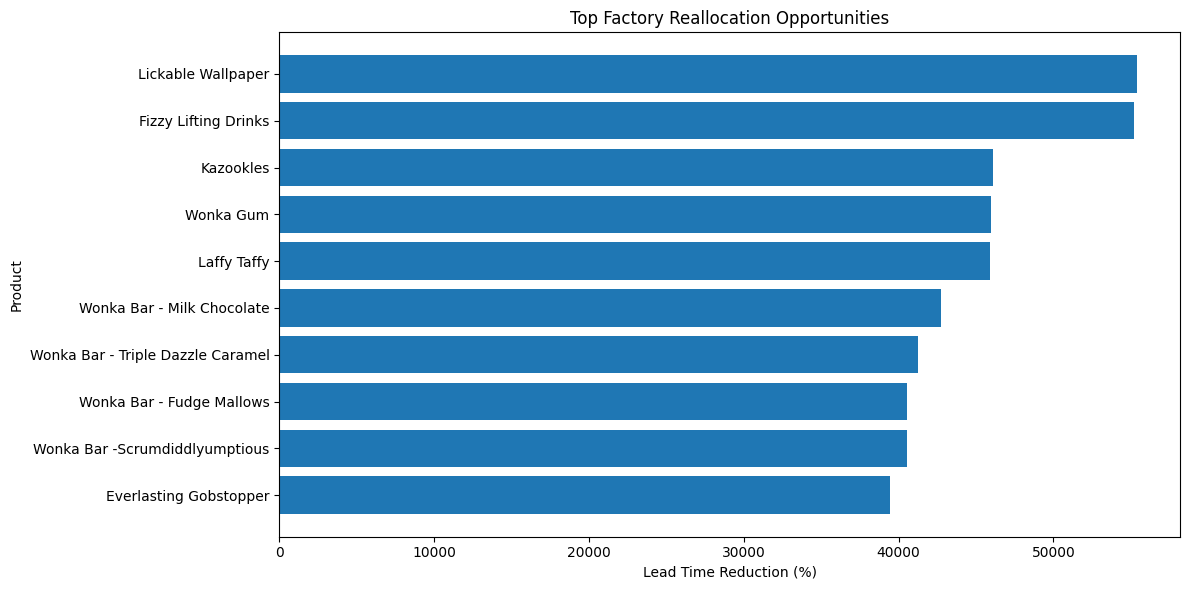

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import matplotlib.pyplot as plt
from google.colab import files

plot_data = (
    top_recommendations
    .sort_values(
        "Lead_Time_Reduction_%",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_data["Product Name"],
    plot_data["Lead_Time_Reduction_%"]
)

plt.xlabel("Lead Time Reduction (%)")
plt.ylabel("Product")
plt.title(
    "Top Factory Reallocation Opportunities"
)

plt.gca().invert_yaxis()

plt.tight_layout()

image_file_path = "../05_Results/Top_Factory_Reallocation_Opportunities.png"
plt.savefig(
    image_file_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download(image_file_path)